# EDA — Home Credit Default Risk: `bureau.csv`

## Purpose of this notebook

`bureau.csv` contains credit history reported by **other financial
institutions** to the credit bureau — this is the piece that was
completely missing in v1, and the reason this dataset can support a
genuinely *behavioral* model.

Unlike `application_train.csv`, this table has a **one-to-many**
relationship with clients: a single `SK_ID_CURR` can appear in zero, one,
or many rows here (zero if the client has no external credit history on
record, many if they have several loans/cards elsewhere).

This notebook:

1. Loads the table and checks its shape/types
2. Explores the one-to-many relationship with `SK_ID_CURR`
3. Reviews missing values
4. Looks at key categorical fields (`CREDIT_ACTIVE`, `CREDIT_TYPE`)
5. Looks at key numeric fields (overdue amounts, credit sums, recency)
6. Does an early aggregation-and-merge test: does a simple per-client
   summary of this table already correlate with the target?


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

bureau = pd.read_csv("../data/raw/home_credit/bureau.csv")
print(f"Shape: {bureau.shape[0]:,} rows x {bureau.shape[1]} columns")
bureau.head()

Shape: 1,716,428 rows x 17 columns


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


## 1. Data types and general shape

In [11]:
bureau.info(verbose=False)
print()
print(bureau.dtypes.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Columns: 17 entries, SK_ID_CURR to AMT_ANNUITY
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB

float64    8
int64      6
object     3
Name: count, dtype: int64


## 2. One-to-many relationship with `SK_ID_CURR`

This is the key structural difference from `application_train.csv`. We need
to know: how many bureau records does the average client have, and how many
clients have *none at all* (meaning we'll need to handle missing bureau
history as a real, meaningful category — not just an NaN to impute away).

In [12]:
n_bureau_rows = len(bureau)
n_unique_clients_in_bureau = bureau["SK_ID_CURR"].nunique()

app_train = pd.read_csv("../data/raw/home_credit/application_train.csv", usecols=["SK_ID_CURR", "TARGET"])
n_total_clients = app_train["SK_ID_CURR"].nunique()
n_clients_with_no_bureau_record = n_total_clients - n_unique_clients_in_bureau

print(f"Total bureau rows: {n_bureau_rows:,}")
print(f"Unique clients WITH at least one bureau record: {n_unique_clients_in_bureau:,}")
print(f"Total clients in application_train: {n_total_clients:,}")
print(f"Clients with NO bureau record at all: {n_clients_with_no_bureau_record:,} "
      f"({n_clients_with_no_bureau_record / n_total_clients:.1%})")

records_per_client = bureau.groupby("SK_ID_CURR").size()
print()
print("Distribution of bureau records per client (clients WITH at least 1 record):")
print(records_per_client.describe())

Total bureau rows: 1,716,428
Unique clients WITH at least one bureau record: 305,811
Total clients in application_train: 307,511
Clients with NO bureau record at all: 1,700 (0.6%)

Distribution of bureau records per client (clients WITH at least 1 record):
count    305811.000000
mean          5.612709
std           4.430354
min           1.000000
25%           2.000000
50%           4.000000
75%           8.000000
max         116.000000
dtype: float64


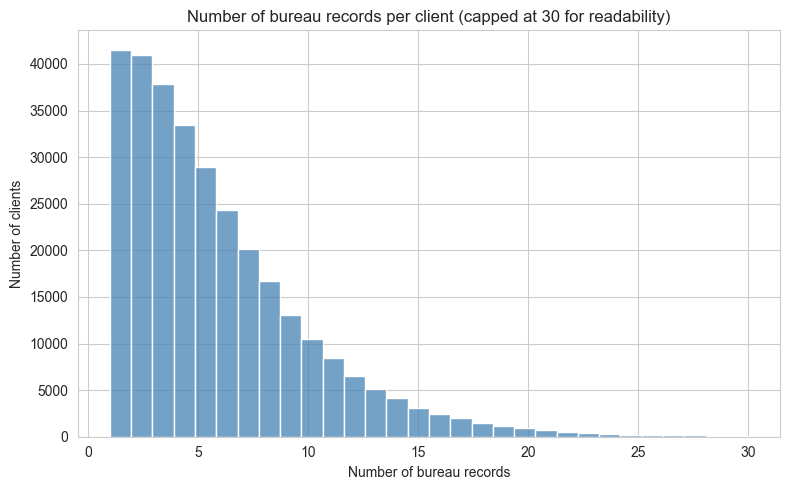

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(records_per_client[records_per_client <= 30], bins=30, color="steelblue")
plt.title("Number of bureau records per client (capped at 30 for readability)")
plt.xlabel("Number of bureau records")
plt.ylabel("Number of clients")
plt.tight_layout()
plt.show()

## 3. Missing values overview

In [14]:
missing = bureau.isna().sum()
missing_pct = (missing / len(bureau) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(missing_pct)

AMT_ANNUITY               71.473490
AMT_CREDIT_MAX_OVERDUE    65.513264
DAYS_ENDDATE_FACT         36.916958
AMT_CREDIT_SUM_LIMIT      34.477415
AMT_CREDIT_SUM_DEBT       15.011932
DAYS_CREDIT_ENDDATE        6.149573
AMT_CREDIT_SUM             0.000757
dtype: float64


## 4. Key categorical fields

`CREDIT_ACTIVE` tells us whether each reported credit is still open,
closed, sold, or in bad debt. `CREDIT_TYPE` tells us what kind of credit
product it was (car loan, credit card, consumer credit, etc.).

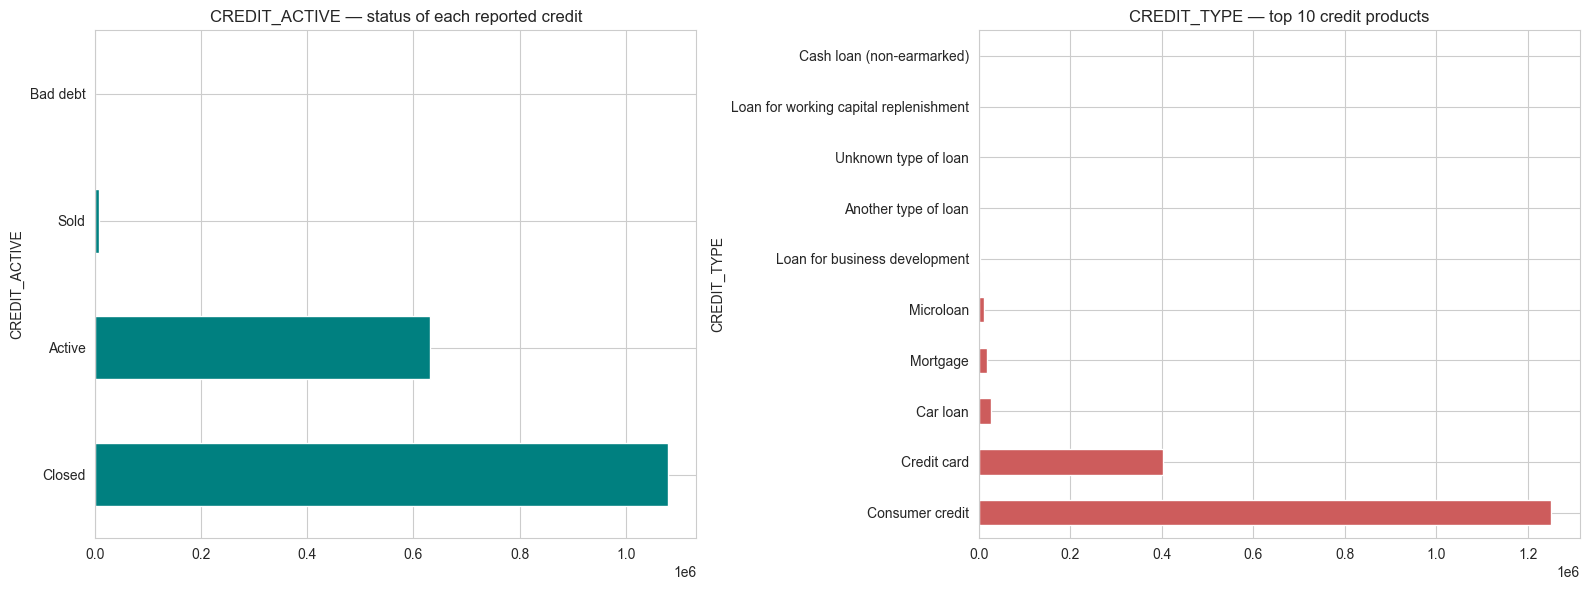

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bureau["CREDIT_ACTIVE"].value_counts().plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("CREDIT_ACTIVE — status of each reported credit")

bureau["CREDIT_TYPE"].value_counts().head(10).plot(kind="barh", ax=axes[1], color="indianred")
axes[1].set_title("CREDIT_TYPE — top 10 credit products")

plt.tight_layout()
plt.show()

## 5. Key numeric fields

- `DAYS_CREDIT`: how many days before the current application this credit
  was opened (negative = in the past — same convention as `DAYS_BIRTH`)
- `CREDIT_DAY_OVERDUE`: how many days this specific credit is/was overdue
- `AMT_CREDIT_SUM`: total credit amount for that record
- `AMT_CREDIT_SUM_DEBT`: current debt outstanding on that record

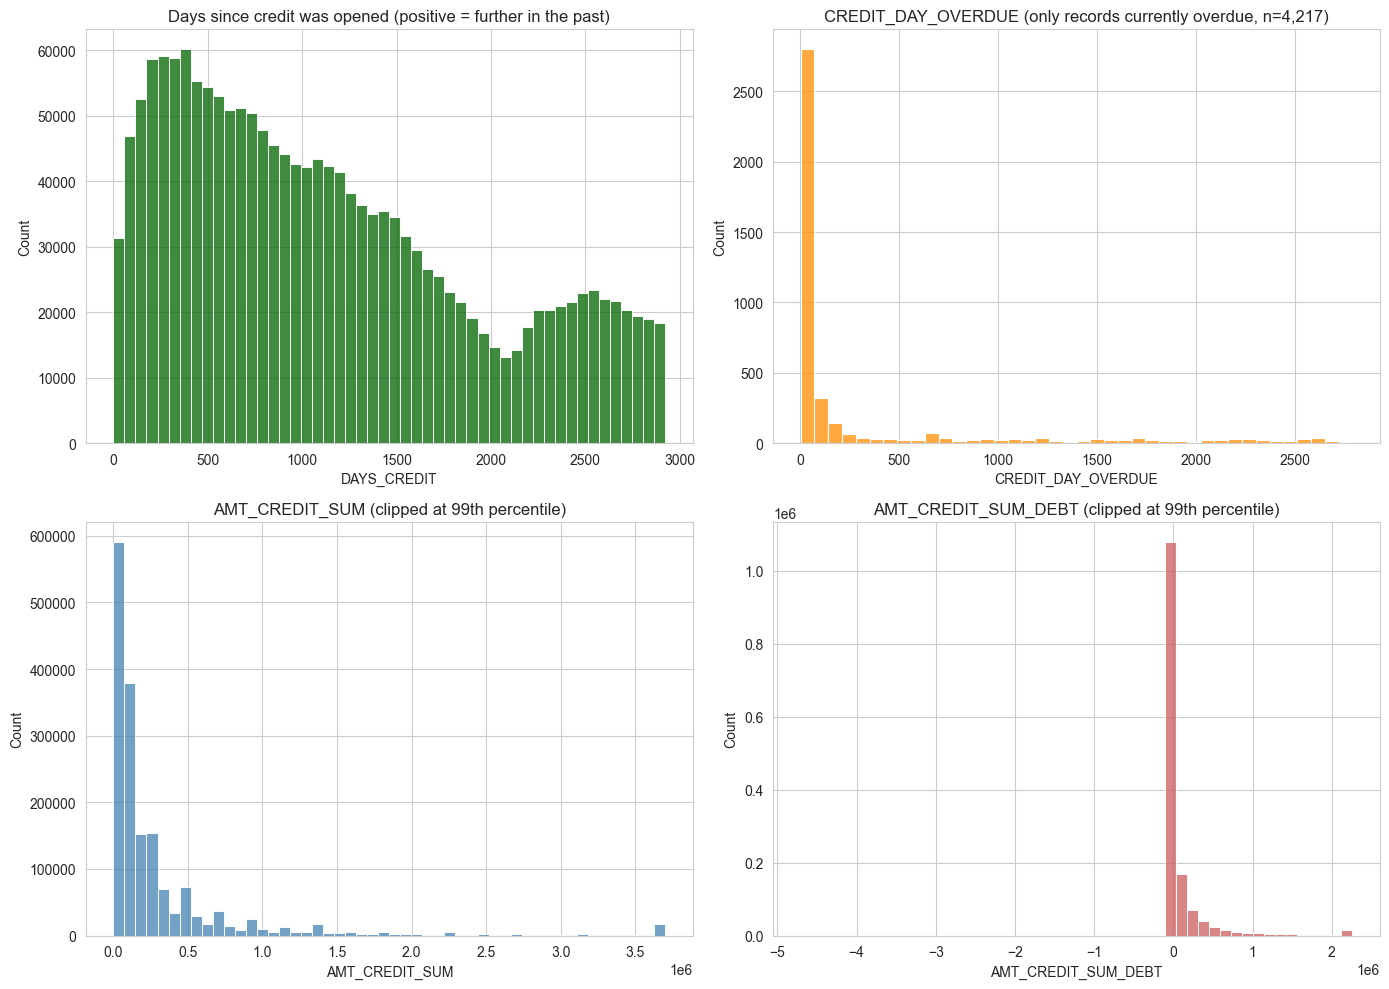

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(-bureau["DAYS_CREDIT"], bins=50, ax=axes[0, 0], color="darkgreen")
axes[0, 0].set_title("Days since credit was opened (positive = further in the past)")

overdue_nonzero = bureau.loc[bureau["CREDIT_DAY_OVERDUE"] > 0, "CREDIT_DAY_OVERDUE"]
sns.histplot(overdue_nonzero, bins=40, ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title(f"CREDIT_DAY_OVERDUE (only records currently overdue, n={len(overdue_nonzero):,})")

sns.histplot(bureau["AMT_CREDIT_SUM"].dropna().clip(upper=bureau["AMT_CREDIT_SUM"].quantile(0.99)),
             bins=50, ax=axes[1, 0], color="steelblue")
axes[1, 0].set_title("AMT_CREDIT_SUM (clipped at 99th percentile)")

sns.histplot(bureau["AMT_CREDIT_SUM_DEBT"].dropna().clip(upper=bureau["AMT_CREDIT_SUM_DEBT"].quantile(0.99)),
             bins=50, ax=axes[1, 1], color="indianred")
axes[1, 1].set_title("AMT_CREDIT_SUM_DEBT (clipped at 99th percentile)")

plt.tight_layout()
plt.show()

## 6. Early signal check: does a simple per-client summary correlate with the target?

This is the test that matters most for deciding whether this table is worth
the engineering effort. We build a *minimal* per-client summary (just 4
aggregates) — nowhere near the final feature set — merge it with the
target, and check whether clients who defaulted look different from those
who didn't, even at this crude level.

In [17]:
bureau_summary = bureau.groupby("SK_ID_CURR").agg(
    BUREAU_COUNT=("SK_ID_BUREAU", "count"),
    BUREAU_ACTIVE_COUNT=("CREDIT_ACTIVE", lambda x: (x == "Active").sum()),
    BUREAU_MAX_OVERDUE_DAYS=("CREDIT_DAY_OVERDUE", "max"),
    BUREAU_TOTAL_DEBT=("AMT_CREDIT_SUM_DEBT", "sum"),
).reset_index()

merged = app_train.merge(bureau_summary, on="SK_ID_CURR", how="left")

# Clients with no bureau record get NaN from the merge — fill with 0 for
# count-type columns (no records = 0 credits, not missing information)
merged["BUREAU_COUNT"] = merged["BUREAU_COUNT"].fillna(0)
merged["BUREAU_ACTIVE_COUNT"] = merged["BUREAU_ACTIVE_COUNT"].fillna(0)
merged["HAS_BUREAU_HISTORY"] = (merged["BUREAU_COUNT"] > 0).astype(int)

print("Default rate by whether the client has ANY bureau history:")
print(merged.groupby("HAS_BUREAU_HISTORY")["TARGET"].mean())
print()
print("Mean values by TARGET (0 = repaid, 1 = defaulted):")
print(merged.groupby("TARGET")[["BUREAU_COUNT", "BUREAU_ACTIVE_COUNT", "BUREAU_MAX_OVERDUE_DAYS"]].mean())

Default rate by whether the client has ANY bureau history:
HAS_BUREAU_HISTORY
0    0.101249
1    0.077301
Name: TARGET, dtype: float64

Mean values by TARGET (0 = repaid, 1 = defaulted):
        BUREAU_COUNT  BUREAU_ACTIVE_COUNT  BUREAU_MAX_OVERDUE_DAYS
TARGET                                                            
0           4.778464             1.738972                 4.631043
1           4.613092             2.027633                 6.464356


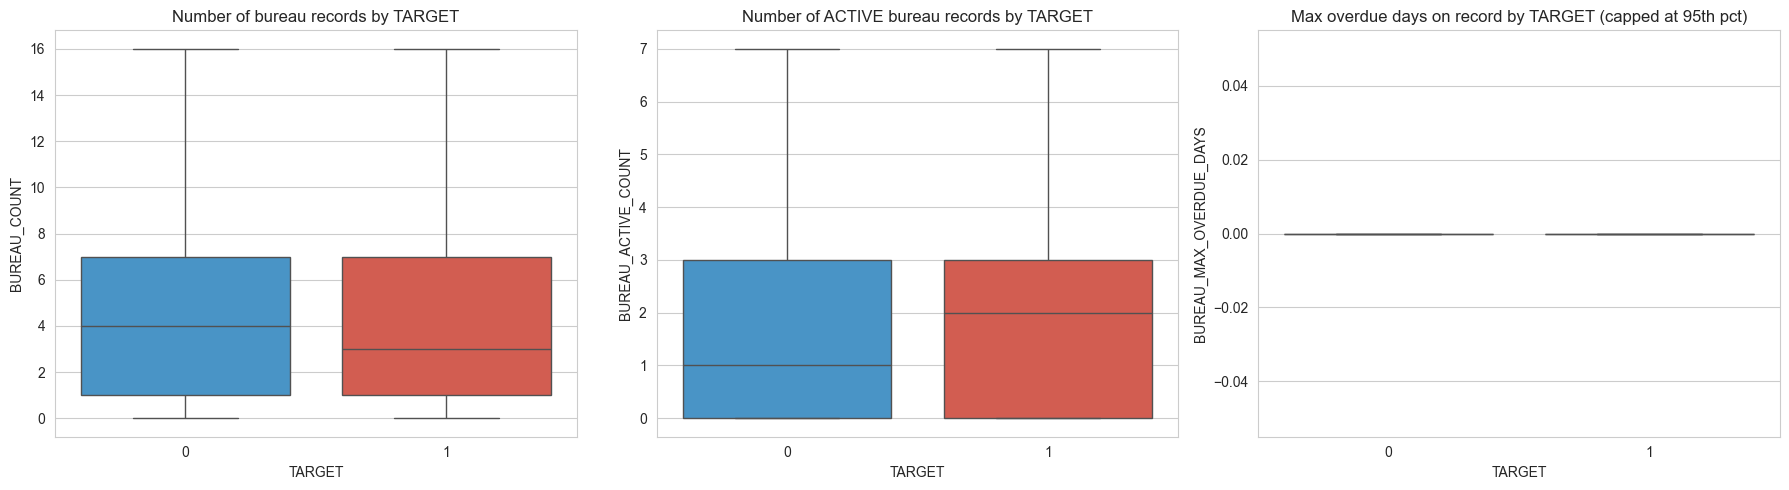

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=merged, x="TARGET", y="BUREAU_COUNT", hue="TARGET",
            showfliers=False, palette=["#3498db", "#e74c3c"], legend=False, ax=axes[0])
axes[0].set_title("Number of bureau records by TARGET")

sns.boxplot(data=merged, x="TARGET", y="BUREAU_ACTIVE_COUNT", hue="TARGET",
            showfliers=False, palette=["#3498db", "#e74c3c"], legend=False, ax=axes[1])
axes[1].set_title("Number of ACTIVE bureau records by TARGET")

overdue_capped = merged["BUREAU_MAX_OVERDUE_DAYS"].clip(upper=merged["BUREAU_MAX_OVERDUE_DAYS"].quantile(0.95))
sns.boxplot(x=merged["TARGET"], y=overdue_capped, hue=merged["TARGET"],
            showfliers=False, palette=["#3498db", "#e74c3c"], legend=False, ax=axes[2])
axes[2].set_title("Max overdue days on record by TARGET (capped at 95th pct)")

plt.tight_layout()
plt.show()

## 7. Fixing a blind spot: overdue events are too rare for a boxplot

`CREDIT_DAY_OVERDUE > 0` only happens in 0.25% of bureau rows — averages and
boxplots on the raw value get dominated by zeros. A binary flag ("did this
client EVER have an overdue credit on record?") is a much more honest way
to check whether this carries signal.

In [19]:
bureau_overdue_flag = bureau.groupby("SK_ID_CURR")["CREDIT_DAY_OVERDUE"].apply(
    lambda x: (x > 0).any()
).astype(int).rename("EVER_OVERDUE")

merged_flag = app_train.merge(bureau_overdue_flag, on="SK_ID_CURR", how="left")
merged_flag["EVER_OVERDUE"] = merged_flag["EVER_OVERDUE"].fillna(0)

print("Default rate by EVER_OVERDUE (0 = never overdue in bureau history, 1 = at least once):")
print(merged_flag.groupby("EVER_OVERDUE")["TARGET"].agg(["mean", "count"]))

Default rate by EVER_OVERDUE (0 = never overdue in bureau history, 1 = at least once):
                  mean   count
EVER_OVERDUE                  
0.0           0.079855  304114
1.0           0.158964    3397


## 8. Summary and next steps

- 0.6% of clients (1,700 of 307,511) have zero bureau history — a small share, but `HAS_BUREAU_HISTORY` still carries signal (see below).
- The typical client has 4-6 bureau records (mean 5.6, median 4), though the distribution has a long tail (up to 116 for a few outliers).
- `HAS_BUREAU_HISTORY` shows a counterintuitive but real effect: clients with **no** bureau history default at a **higher** rate (10.1%) than those with history (7.7%) — consistent with the "credit invisible" phenomenon in credit scoring literature.
- `BUREAU_COUNT` and `BUREAU_ACTIVE_COUNT` show only modest separation by target (means of 4.78 vs. 4.61, and 1.74 vs. 2.03 respectively) — real but weak on their own.
- `BUREAU_MAX_OVERDUE_DAYS` looked flat in the boxplot because overdue events are extremely rare (0.25% of rows) — the boxplot was misleading due to that sparsity.
- Converting overdue history into a binary flag (`EVER_OVERDUE`) revealed a much stronger signal hidden by the sparsity: clients who were ever overdue on a bureau-reported credit default at **15.9%**, versus **8.0%** for those who never were — roughly double the risk, affecting about 1.1% of clients.

**Conclusion:** `bureau.csv` carries genuine behavioral signal, both through simple aggregates (`HAS_BUREAU_HISTORY`, `BUREAU_ACTIVE_COUNT`) and — more importantly — through a rare-event binary flag (`EVER_OVERDUE`) that a naive boxplot would have missed. This is a methodological lesson worth carrying into the remaining tables: check rare/sparse events as binary flags, not just as raw averages.

**Next step:** `previous_application.csv` — this institution's own history with the client — followed by the payment-level tables (`installments_payments.csv`, `credit_card_balance.csv`), which is where the truly granular behavioral/temporal patterns live.